In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print(os.getcwd())
print(os.listdir())

d:\instacard_market_basket_project
['data', 'market_basket_analysis.ipynb']


In [5]:
orders = pd.read_csv("data/orders.csv")
products = pd.read_csv("data/products.csv")
aisles = pd.read_csv("data/aisles.csv")
departments = pd.read_csv("data/departments.csv")

print("orders:", orders.shape)
print("products:", products.shape)
print("aisles:", aisles.shape)
print("departments:", departments.shape)

orders: (3421083, 7)
products: (49688, 4)
aisles: (134, 2)
departments: (21, 2)


In [6]:
prior = pd.read_csv("data/order_products__prior.csv", nrows=2000000)
train = pd.read_csv("data/order_products__train.csv")

print("prior:", prior.shape)
print("train:", train.shape)

prior: (2000000, 4)
train: (1384617, 4)


In [7]:
orders.head(10)

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
5,3367565,1,prior,6,2,7,19.0
6,550135,1,prior,7,1,9,20.0
7,3108588,1,prior,8,1,14,14.0
8,2295261,1,prior,9,1,16,0.0
9,2550362,1,prior,10,4,8,30.0


In [9]:
orders.info()
orders.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB


order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

In [10]:
print("Total orders:", orders["order_id"].nunique())
print("Total customers:", orders["user_id"].nunique())
print("Total products:", products["product_id"].nunique())
print("Departments:", departments.shape[0])
print("Aisles:", aisles.shape[0])
print("Har customer ke average orders:", round(orders.groupby("user_id")["order_number"].max().mean(), 1))

Total orders: 3421083
Total customers: 206209
Total products: 49688
Departments: 21
Aisles: 134
Har customer ke average orders: 16.6


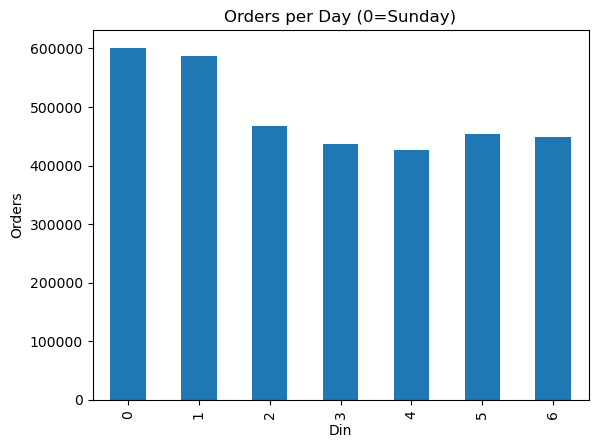

In [12]:
orders["order_dow"].value_counts().sort_index().plot(kind="bar", title="Orders per Day (0=Sunday)")
plt.xlabel("Din")
plt.ylabel("Orders")
plt.show()

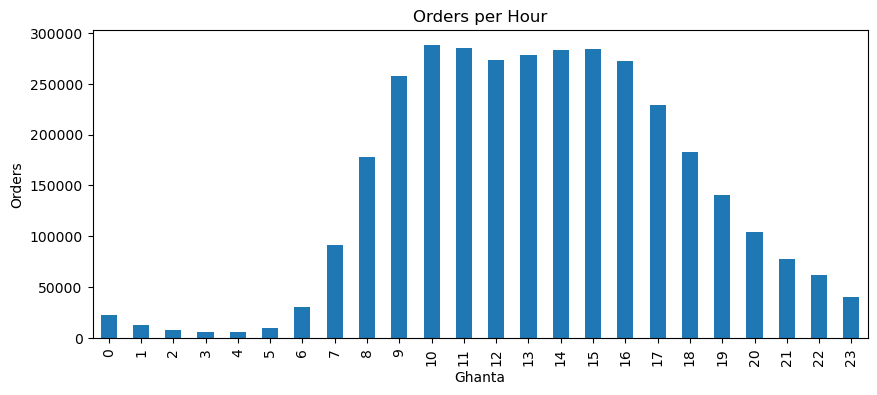

In [13]:
orders["order_hour_of_day"].value_counts().sort_index().plot(kind="bar", figsize=(10,4), title="Orders per Hour")
plt.xlabel("Ghanta")
plt.ylabel("Orders")
plt.show()

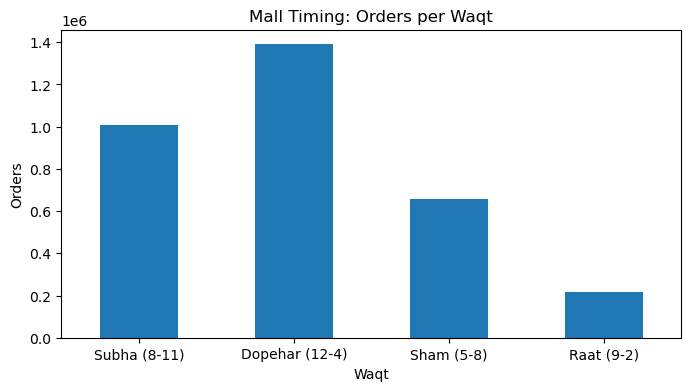

time_of_day
Dopehar (12-4)    42.5
Subha (8-11)      30.9
Sham (5-8)        20.1
Raat (9-2)         6.6
Name: proportion, dtype: float64


In [14]:
def time_of_day(h):
    if 8 <= h <= 11:
        return "Subha (8-11)"
    elif 12 <= h <= 16:
        return "Dopehar (12-4)"
    elif 17 <= h <= 20:
        return "Sham (5-8)"
    elif h >= 21 or h <= 1:
        return "Raat (9-2)"
    else:
        return "Band (2-8)"

orders["time_of_day"] = orders["order_hour_of_day"].apply(time_of_day)

# Sirf mall ke khule ghantay
mall = orders[orders["time_of_day"] != "Band (2-8)"]

order_list = ["Subha (8-11)", "Dopehar (12-4)", "Sham (5-8)", "Raat (9-2)"]

mall["time_of_day"].value_counts().reindex(order_list).plot(
    kind="bar", figsize=(8,4), title="Mall Timing: Orders per Waqt", rot=0)
plt.xlabel("Waqt")
plt.ylabel("Orders")
plt.show()

print((mall["time_of_day"].value_counts(normalize=True) * 100).round(1))

In [15]:
print("Total orders:", orders["order_id"].nunique())
print("Total customers:", orders["user_id"].nunique())
print("Total products:", products["product_id"].nunique())
print("Departments:", departments.shape[0])
print("Aisles:", aisles.shape[0])
print("Har customer ke average orders:", round(orders.groupby("user_id")["order_number"].max().mean(), 1))

Total orders: 3421083
Total customers: 206209
Total products: 49688
Departments: 21
Aisles: 134
Har customer ke average orders: 16.6


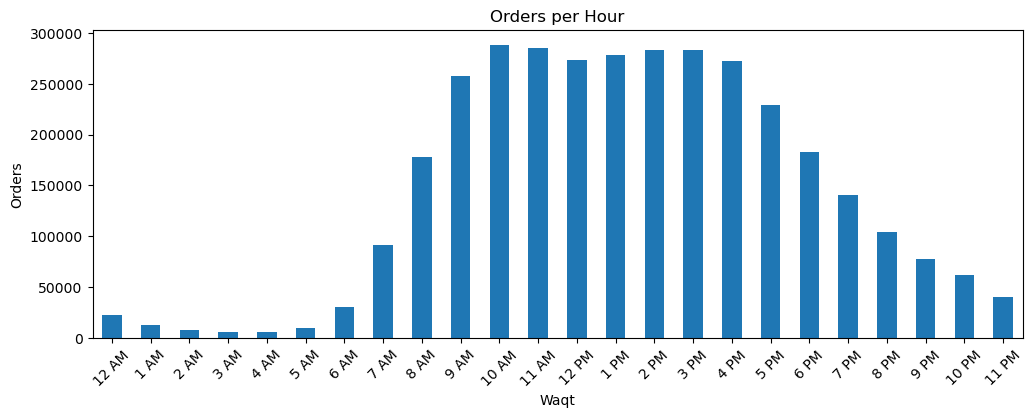

In [16]:
def to_ampm(h):
    suffix = "AM" if h < 12 else "PM"
    hour12 = h % 12
    if hour12 == 0:
        hour12 = 12
    return f"{hour12} {suffix}"

counts = orders["order_hour_of_day"].value_counts().sort_index()
counts.index = counts.index.map(to_ampm)

counts.plot(kind="bar", figsize=(12,4), title="Orders per Hour")
plt.xlabel("Waqt")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

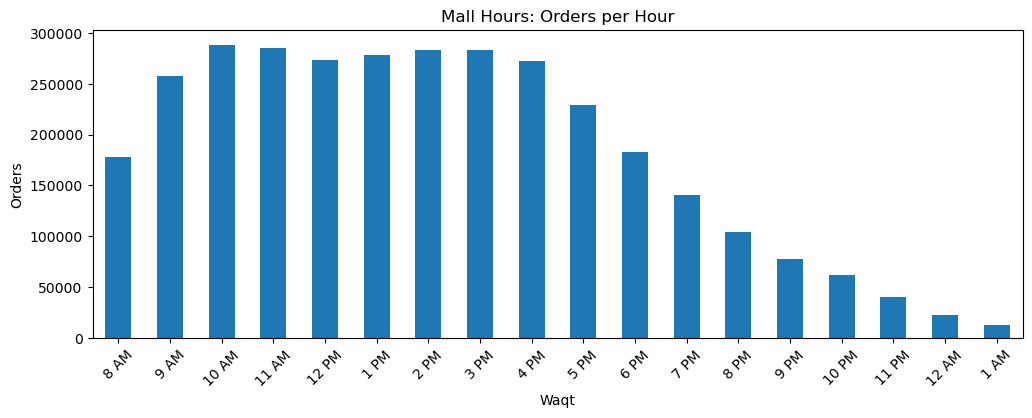

In [17]:
mall_hours = [8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,0,1]

counts = orders["order_hour_of_day"].value_counts().reindex(mall_hours)
counts.index = counts.index.map(to_ampm)

counts.plot(kind="bar", figsize=(12,4), title="Mall Hours: Orders per Hour")
plt.xlabel("Waqt")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

In [18]:
hourly = orders["order_hour_of_day"].value_counts()

print("Sab se zyada rush ka ghanta:", hourly.idxmax(), "baje")
print("Sab se kam rush ka ghanta:", hourly.idxmin(), "baje")

daily = orders["order_dow"].value_counts()
print("Sab se busy din (0=Sunday):", daily.idxmax())
print("Sab se kam busy din:", daily.idxmin())

Sab se zyada rush ka ghanta: 10 baje
Sab se kam rush ka ghanta: 3 baje
Sab se busy din (0=Sunday): 0
Sab se kam busy din: 4


In [19]:
print("Total orders:", orders["order_id"].nunique())
print("Total customers:", orders["user_id"].nunique())
print("Avg orders per customer:", round(orders.groupby("user_id")["order_number"].max().mean(), 1))
print("Reorder %:", round(prior["reordered"].mean() * 100, 1))
print("Sab se busy ghanta:", orders["order_hour_of_day"].value_counts().idxmax())
print("Sab se busy din (number):", orders["order_dow"].value_counts().idxmax())
print("Aam gap (din):", orders["days_since_prior_order"].mode()[0])

Total orders: 3421083
Total customers: 206209
Avg orders per customer: 16.6
Reorder %: 59.0
Sab se busy ghanta: 10
Sab se busy din (number): 0
Aam gap (din): 30.0


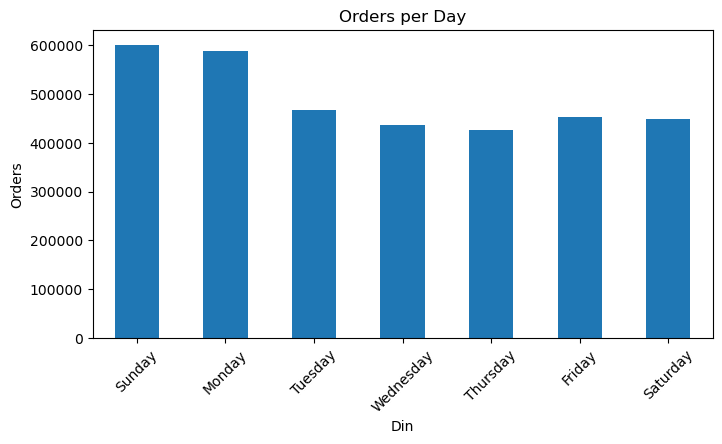

In [20]:
days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

counts = orders["order_dow"].value_counts().sort_index()
counts.index = counts.index.map(lambda d: days[d])

counts.plot(kind="bar", figsize=(8,4), title="Orders per Day", rot=45)
plt.xlabel("Din")
plt.ylabel("Orders")
plt.show()

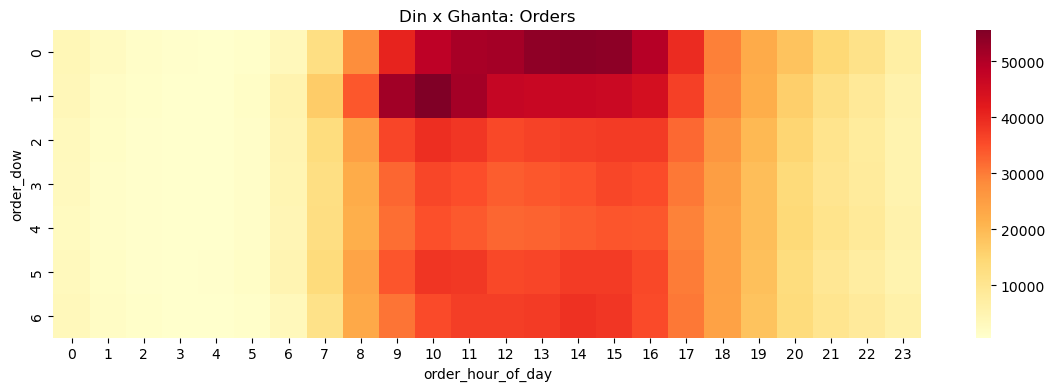

In [21]:
# pehli baar: !pip install seaborn
import seaborn as sns

pivot = orders.pivot_table(index="order_dow", columns="order_hour_of_day",
                           values="order_id", aggfunc="count")
plt.figure(figsize=(14,4))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Din x Ghanta: Orders")
plt.show()

count    198086.000000
mean         10.096625
std           7.536547
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
dtype: float64


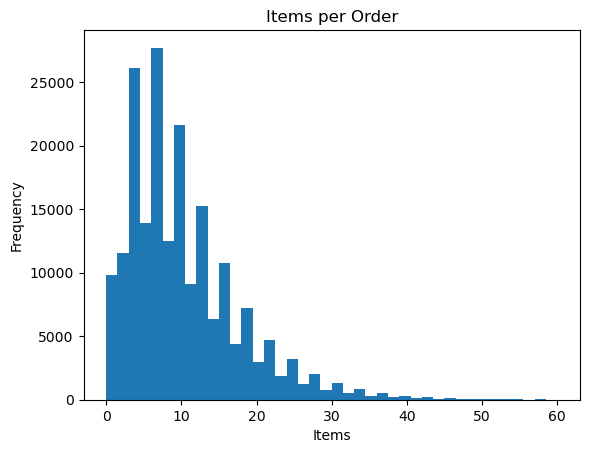

In [22]:
basket_size = prior.groupby("order_id").size()
print(basket_size.describe())

basket_size.plot(kind="hist", bins=40, range=(0,60), title="Items per Order")
plt.xlabel("Items")
plt.ylabel("Frequency")
plt.show()

In [23]:
full = (prior.merge(products, on="product_id")
             .merge(aisles, on="aisle_id")
             .merge(departments, on="department_id"))
full.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


                  items  reorder_rate
department                           
produce          583911          65.0
dairy eggs       333934          66.9
snacks           178225          57.6
beverages        165799          65.2
frozen           138323          54.1
pantry           115310          34.9
bakery            72390          63.0
canned goods      65708          46.0
deli              65056          60.4
dry goods pasta   53110          46.0
household         45464          40.4
meat seafood      43869          56.8
breakfast         43773          55.9
personal care     27740          31.9
babies            26433          57.9
international     16896          36.4
alcohol            9339          57.7
pets               6144          60.8
missing            4235          40.3
other              2228          43.0
bulk               2113          57.6


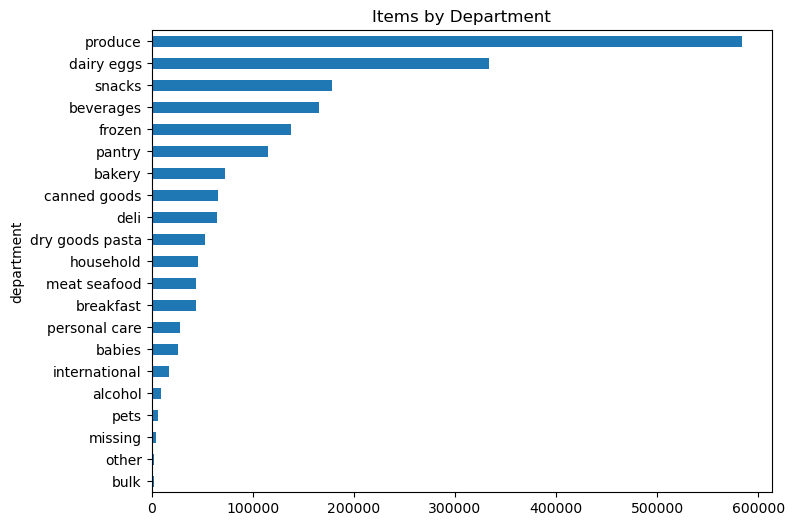

In [24]:
dept = full.groupby("department").agg(items=("product_id", "count"),
                                      reorder_rate=("reordered", "mean"))
dept["reorder_rate"] = (dept["reorder_rate"] * 100).round(1)
dept = dept.sort_values("items", ascending=False)
print(dept)

dept["items"].sort_values().plot(kind="barh", figsize=(8,6), title="Items by Department")
plt.show()

product_name
Banana                    6832
Bag of Organic Bananas    4894
Organic Whole Milk        1888
Organic Strawberries      1695
Organic Baby Spinach      1505
Organic Hass Avocado      1464
Organic Avocado           1344
Strawberries              1012
Spring Water               994
Organic Raspberries        878
Name: count, dtype: int64


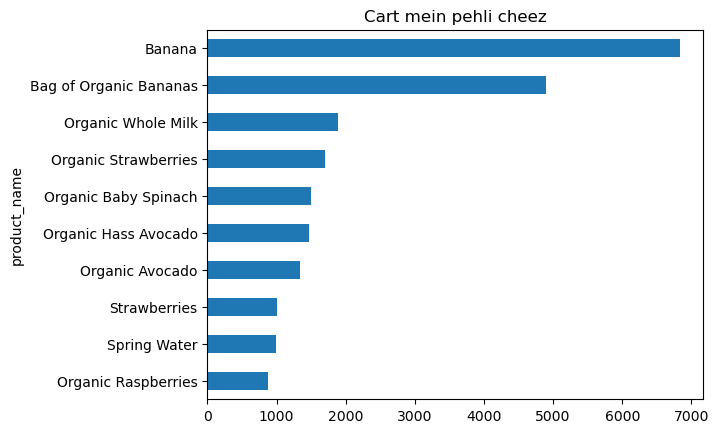

In [25]:
first = full[full["add_to_cart_order"] == 1]["product_name"].value_counts().head(10)
print(first)
first.sort_values().plot(kind="barh", title="Cart mein pehli cheez")
plt.show()

group
Regular    54.3
Wafadar    24.6
Naya       21.1
Name: proportion, dtype: float64
group
Naya       20.0
Regular    16.6
Wafadar     9.0
Name: avg_gap, dtype: float64


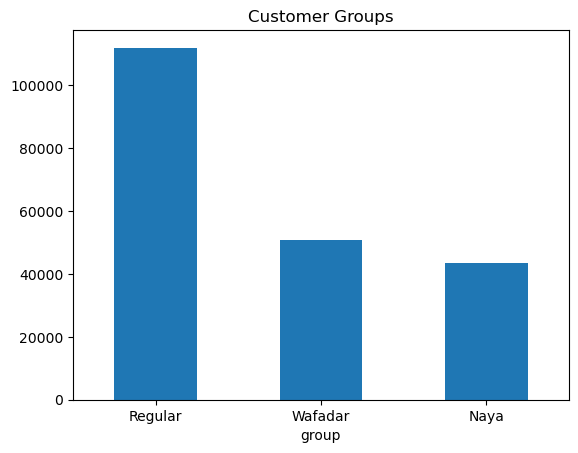

In [26]:
cust = orders.groupby("user_id").agg(total_orders=("order_number", "max"),
                                     avg_gap=("days_since_prior_order", "mean"))

def group(n):
    if n <= 5:
        return "Naya"
    elif n <= 20:
        return "Regular"
    else:
        return "Wafadar"

cust["group"] = cust["total_orders"].apply(group)

print(cust["group"].value_counts(normalize=True).mul(100).round(1))
print(cust.groupby("group")["avg_gap"].mean().round(1))

cust["group"].value_counts().plot(kind="bar", rot=0, title="Customer Groups")
plt.show()

Dairy eggs ke total items: 333934
Peak ghanta: 10 AM
Sab se kam ghanta: 4 AM
Top 3 ghantay: ['10 AM', '11 AM', '3 PM']


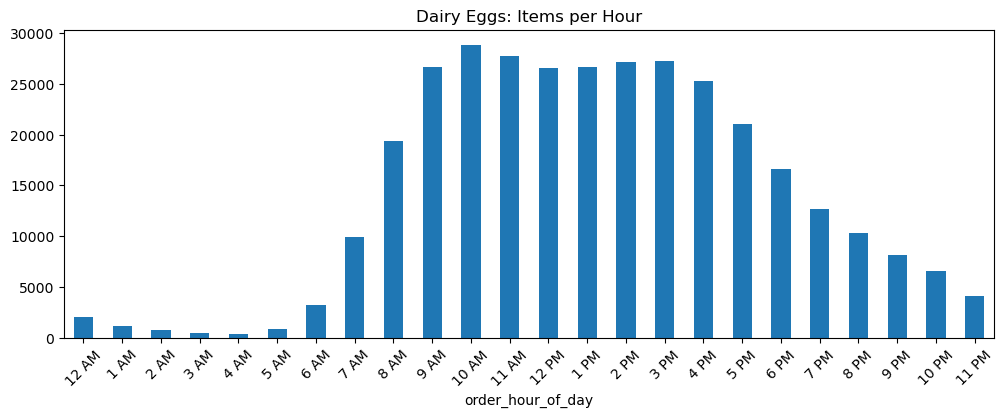

Peak din: Sunday
Sab se kam din: Thursday


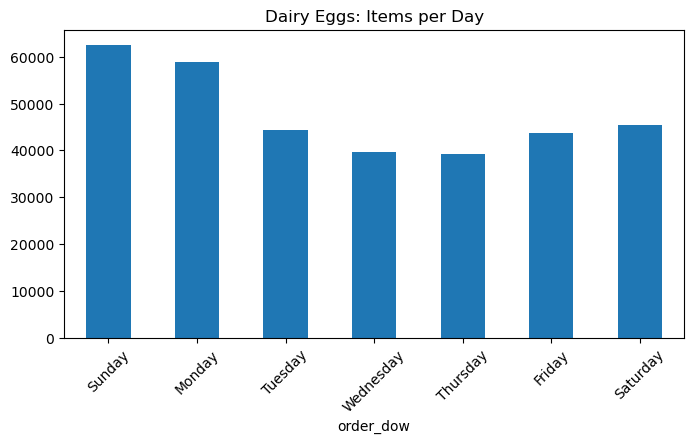

In [27]:
days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

def to_ampm(h):
    hour12 = h % 12 or 12
    return f"{hour12} {'AM' if h < 12 else 'PM'}"

# Dairy eggs ke items + order ka waqt
dairy = (prior.merge(products, on="product_id")
              .merge(departments, on="department_id")
              .merge(orders[["order_id", "order_dow", "order_hour_of_day"]], on="order_id"))
dairy = dairy[dairy["department"] == "dairy eggs"]

print("Dairy eggs ke total items:", len(dairy))

# Ghantay
hours = dairy["order_hour_of_day"].value_counts().sort_index()
print("Peak ghanta:", to_ampm(hours.idxmax()))
print("Sab se kam ghanta:", to_ampm(hours.idxmin()))
print("Top 3 ghantay:", [to_ampm(h) for h in hours.nlargest(3).index])

h = hours.copy()
h.index = h.index.map(to_ampm)
h.plot(kind="bar", figsize=(12,4), title="Dairy Eggs: Items per Hour", rot=45)
plt.show()

# Din
dow = dairy["order_dow"].value_counts().sort_index()
print("Peak din:", days[dow.idxmax()])
print("Sab se kam din:", days[dow.idxmin()])

d = dow.copy()
d.index = d.index.map(lambda x: days[x])
d.plot(kind="bar", figsize=(8,4), title="Dairy Eggs: Items per Day", rot=45)
plt.show()